# Tarea 1 de Fisica computacional 
Diferentes metodos para aproximar $\pi$

1. leibniz_pi(N)

$
\pi
\approx
4 \sum_{n=0}^{\infty}
\frac{(-1)^n}{2n+1}
$

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def leibniz_pi(N):
    x = 0

    for n in range(N):
        x += (-1)**n / (2*n + 1)
        resultado= 4 * x

        return resultado
    
for i in range (1, 6):
    print (leibniz_pi(10** i))

4.0
4.0
4.0
4.0
4.0


2. Nilakantha_(N)

$\pi
\approx
3+
4\sum_{n=1}^{N}
\frac{(-1)^{n+1}}
{(2n)(2n+1)(2n+2)}$

In [28]:
def nilakantha_pi(N):
    x = 3.0

    for n in range(1, N + 1):
        termino = 4 * (-1)**(n + 1) / ((2*n) * (2*n + 1) * (2*n + 2))
        x += termino

    return x
for i in range (1, 6):
    print (nilakantha_pi(10** i))
    
print(np.pi , "<- Real" )

3.1414067184965018
3.1415924109719824
3.141592653340544
3.141592653589538
3.1415926535897865
3.141592653589793 <- Real


3. Viete_pi(N)



$\frac{2}{\pi}= \frac{\sqrt{2}}{2}  \frac{\sqrt{2 + \sqrt{2} }}{2}... $

In [30]:
def viete_pi(N):
    x=1 
    r2=0
    
    for n in range(N):
        r2=np.sqrt(2 + r2)
        x*= r2 / 2
        pi=2/x
    return pi

for i in range (1, 6):
    print (viete_pi(10** i))
    
print(np.pi , "<- Real" )

3.1415914215111997
3.141592653589794
3.141592653589794
3.141592653589794
3.141592653589794
3.141592653589793 <- Real


4. Montecarlo_pi(N)

(me da pereza escribir)

In [29]:
def montecarlo_pi(N):
    x = np.random.uniform(0, 1, N)
    y = np.random.uniform(0, 1, N)

    dentro = x**2 + y**2 <= 1

    N_dentro = np.sum(dentro)

    return 4 * N_dentro / N


for i in range (1, 6):
    print (montecarlo_pi(10** i))
    
print(np.pi , "<- Real" )

3.2
2.92
3.104
3.138
3.13624
3.141592653589793 <- Real


# Graficas de Error y Tiempo

In [5]:
import numpy as np
import matplotlib.pyplot as plt

N_valores = [10, 10**2, 10**3, 10**4, 10**5]

errores_leibniz = []
errores_nilakantha = []
errores_viete = []
errores_montecarlo = []

for N in N_valores:

    pi_leibniz = leibniz_pi(N)
    pi_nilakantha = nilakantha_pi(N)
    pi_viete = viete_pi(N)
    pi_montecarlo = montecarlo_pi(N)

    errores_leibniz.append(abs(pi_leibniz - np.pi))
    errores_nilakantha.append(abs(pi_nilakantha - np.pi))
    errores_viete.append(abs(pi_viete - np.pi))
    errores_montecarlo.append(abs(pi_montecarlo - np.pi))


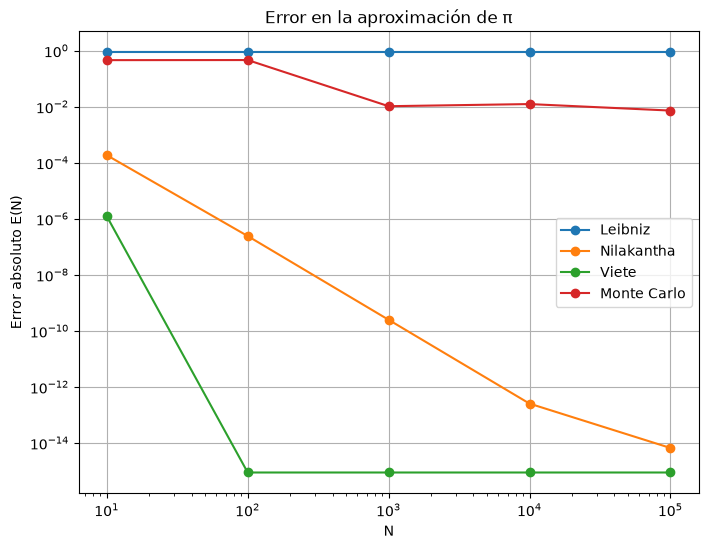

In [32]:
plt.figure(figsize=(8, 6))

plt.loglog(N_valores, errores_leibniz, 'o-', label='Leibniz')
plt.loglog(N_valores, errores_nilakantha, 'o-', label='Nilakantha')
plt.loglog(N_valores, errores_viete, 'o-', label='Viete')
plt.loglog(N_valores, errores_montecarlo, 'o-', label='Monte Carlo')

plt.xlabel('N')
plt.ylabel('Error absoluto E(N)')
plt.title('Error en la aproximación de π')
plt.legend()
plt.grid()
plt.show()

In [8]:
import time

def medir_tiempo(funcion, N):
    tiempos = []

    for _ in range(5):

        inicio = time.perf_counter()

        funcion(N)

        fin = time.perf_counter()

        tiempos.append(fin - inicio)

    return np.mean(tiempos)

tiempos_leibniz = []
tiempos_nilakantha = []
tiempos_viete = []
tiempos_montecarlo = []

for N in N_valores:

    tiempos_leibniz.append(medir_tiempo(leibniz_pi, N))

    tiempos_nilakantha.append(medir_tiempo(nilakantha_pi, N))

    tiempos_viete.append(medir_tiempo(viete_pi, N))

    tiempos_montecarlo.append(medir_tiempo(montecarlo_pi, N))


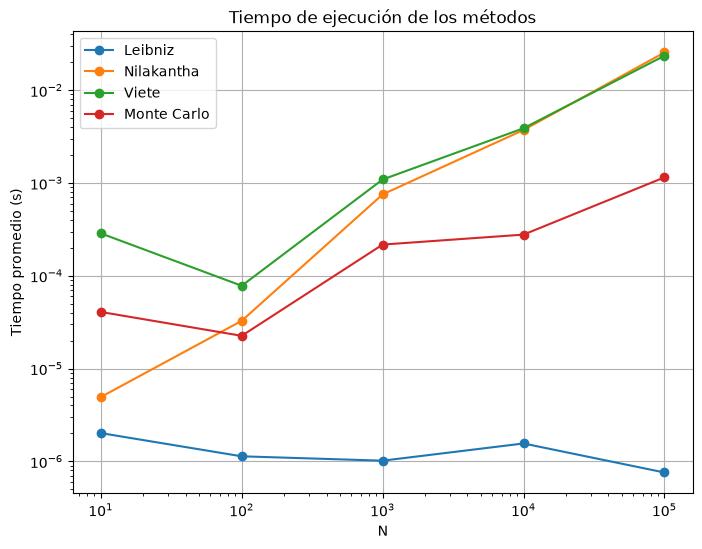

In [31]:
plt.figure(figsize=(8, 6))

plt.loglog(N_valores, tiempos_leibniz, 'o-', label='Leibniz')
plt.loglog(N_valores, tiempos_nilakantha, 'o-', label='Nilakantha')
plt.loglog(N_valores, tiempos_viete, 'o-', label='Viete')
plt.loglog(N_valores, tiempos_montecarlo, 'o-', label='Monte Carlo')

plt.xlabel('N')
plt.ylabel('Tiempo promedio (s)')
plt.title('Tiempo de ejecución de los métodos')
plt.legend()
plt.grid()
plt.show()

# Discusion 

1. Se nota la diferencia de acierto entre los diferentes metodos numericos, ya que unos son mucho ms precisos que otros. En la convergencia, en metodo viete es el mas rapido, ya con el primer termino se acerca al valor de Numpy.pi, en comparación a los otros que se alejan mas.

2. Con montecarlo, la diferencia es que en cada intento varia su precision debido a la aleatoriedad, entonces es doble error entre el metodo usado y al usar los numeros aleatorios.

3. Comparando precision con tiempo de ejecución, basicamente hablando de costo computaciona, el mejor es Viete, aunque en ordenes de magnitud mayores cuesta mas y es preciso, con N=10 ya logra tener una precisión muy buena comparado a los demas metodos.
